# Tests

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np

from src.channels import AWGNChannel, BECChannel
from src.core import PolarCode, PolarEncoder, awgn_frozen_set, bec_frozen_set, sc_decode, sc_decode_llr

N, K = 16, 8
possible_us: list[list[int]] = [[(i >> shift) & 1 for shift in range(K - 1, -1, -1)] for i in range(2 ** K)]
right_counts: list[int] = []
perfect_count: int = 0 #*number of iterations where the decoder decoded all possible combinations correctly
verbose: int = 0
ITERATIONS: int = 1000

for i in range(ITERATIONS):
    per_it_right_count: int = 0
    for u in possible_us:
        epsilon = 0.05
        frozen_bec = bec_frozen_set(N, K, epsilon)
        codeword_bec = PolarEncoder(PolarCode(N, K, frozen_bec)).encode(u)
        # lrs_bec = BECChannel(epsilon).transmit(codeword_bec, mode='lrs')
        llrs_bec = BECChannel(epsilon).transmit(codeword_bec, mode='llrs') #*Log LRs
        # raw_estimate = sc_decode(frozen_bec, codeword_bec, lrs_bec, BECChannel(epsilon))
        raw_estimate = sc_decode_llr(frozen_bec, llrs_bec)
        clean_estimate = np.array([int(raw_estimate[i]) for i in range(raw_estimate.size) if i not in frozen_bec])
        if np.array_equal(u, clean_estimate):
            if verbose >= 2:
                print(f"Is {u} == {clean_estimate}?", True)
            per_it_right_count += 1
        else:
            if verbose >= 2:
                print(f"Is {u} == {clean_estimate}?", False)

    if verbose >= 1:
        print(f"{per_it_right_count} out of {len(possible_us)} were correctly decoded")
    right_counts.append(per_it_right_count)

    if per_it_right_count == len(possible_us):
        perfect_count += 1

percentage: int = (perfect_count / ITERATIONS) * 100
print(f"{perfect_count} / {ITERATIONS} runs decoded correctly ({percentage:.2f} %)")




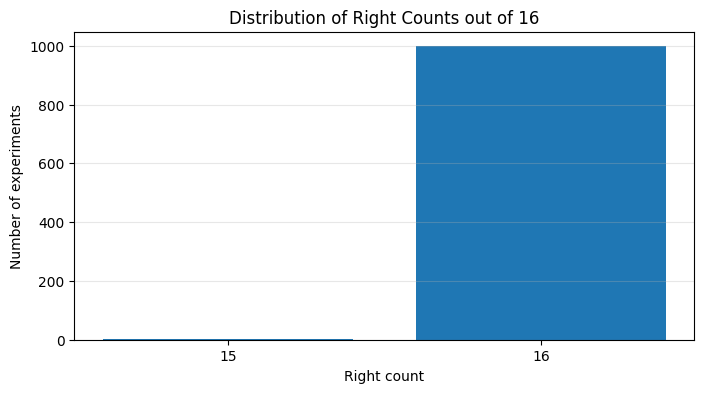

In [4]:
import matplotlib.pyplot as plt
from collections import Counter

count_distribution = Counter(right_counts)

x = sorted(count_distribution.keys())
y = [count_distribution[count] for count in x]

plt.figure(figsize=(8, 4))
plt.bar(x, y, width=0.8)
plt.xlabel("Right count")
plt.ylabel("Number of experiments")
plt.title(f"Distribution of Right Counts out of {len(possible_us)}")
plt.xticks(x)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [17]:
np.float16(1.0 / 0.0)

ZeroDivisionError: float division by zero